In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))

import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import xgboost as xgb
import matplotlib.pyplot as plt
import numpy as np
import joblib

target_map = {0.0:0, 0.5:1, 1: 2} #0 is away win, 1 is draw, 2 is home win


In [2]:
df = pd.read_csv('../data/world_cup_training_data.csv')
df['target'] = df['target'].map(target_map) #make sure the targets are distinct ints for future purposes

#Setting up testing and training dataframes
training_set = df[df['date'] <= '2024-12-31']
test_set = df[(df['date'] > '2024-12-31') & (df['date'] < '2026-06-11')]

In [3]:
features = ['elo_diff', 'home_form', 'away_form', 'h2h', 'home_gd', 'away_gd']
X_train = training_set[features]
y = training_set['target']

z = StandardScaler()
X_scaled = z.fit_transform(X_train)
lr_model = LogisticRegression()
lr_model.fit(X_scaled, y)

xgb_model = xgb.XGBClassifier()
xgb_model.fit(X_train, y)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [4]:
X_test = test_set[features]
y_test = test_set['target']

X_test_scaled = z.transform(X_test)

lr_preds = lr_model.predict(X_test_scaled)
xgb_preds = xgb_model.predict(X_test)

#See who is more accurate
print(f"Logistic Regression Accuracy: {accuracy_score(y_test, lr_preds):.2%}")
print(f"XGBoost Accuracy: {accuracy_score(y_test, xgb_preds):.2%}")


Logistic Regression Accuracy: 61.80%
XGBoost Accuracy: 62.05%


Since XGBoost is slightly more accurate at predicting results we will use it going forward

<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

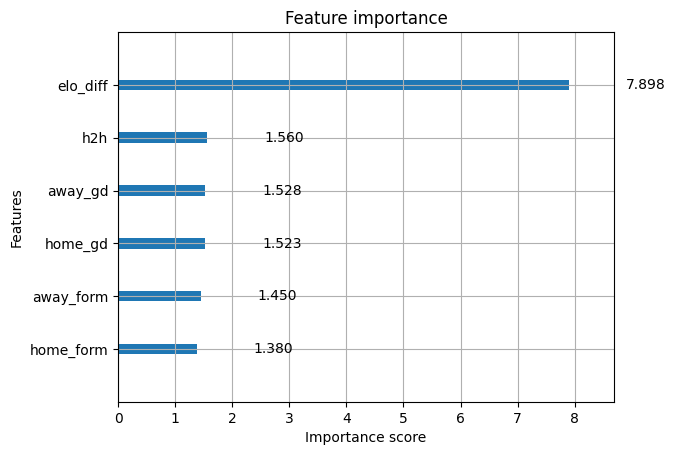

In [5]:
#Finding the MVP
importance_score = xgb_model.get_booster().get_score(importance_type='gain')
xgb.plot_importance(xgb_model, importance_type='gain', values_format='{v:.3f}')


Model values the difference in elo as the most important factor when determining outcome, all other factors have around the same impact which is drastically less than elo_diff

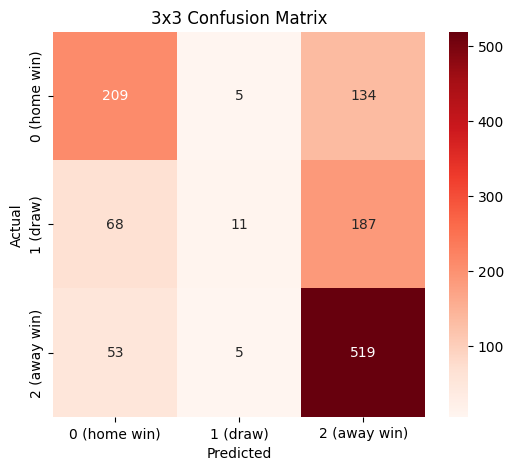

In [6]:
cm = confusion_matrix(y_test, xgb_preds, labels=[0,1,2]) #Confusion matrix

#Displaying the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', 
            xticklabels=['0 (home win)', '1 (draw)', '2 (away win)'], 
            yticklabels=['0 (home win)', '1 (draw)', '2 (away win)'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('3x3 Confusion Matrix')
plt.show()

The model does not predict draws very often, which is a big problem due to draws being a possibility in the WC. As a result, we must fix this issue to assure more reliable predictions for the wc.

To fix this we must find a confidence threshold so where the absolute value of P(Home_Win) - P(Away_win) < draw intevral we return a draw

In [7]:
#Find confidence threshold

probabilites = xgb_model.predict_proba(X_test) #2D array containg the probability of home win, draw, and away win for each match

home, away = probabilites[:, 0], probabilites[:, 2]
diff = np.abs(home - away) #The difference between the probability of a home win vs an away win

#Get a dataframe with all the information to see at what percent_difference the model fails to predict
new = X_test.copy()

new['target'] = y_test.values
new['diff'] = diff
new['predicted'] = xgb_preds    
new['success'] = (new['target'] == new['predicted']).astype(int) #Boolean to see if model predicted correctly

wrong_preds = new[new['success'] == 0] #Dataframe containing all the wrong predictions
confidence_threshold = wrong_preds['diff'].mean()

wrong_preds_draws = wrong_preds[wrong_preds['target'] == 1]
draw_threshold = wrong_preds_draws['diff'].mean()

print("Draw threshold: ", draw_threshold)

Draw threshold:  0.36922324


         elo_diff   home_form   away_form         h2h     home_gd     away_gd  \
count  255.000000  255.000000  255.000000  255.000000  255.000000  255.000000   
mean    15.488667    1.512549    1.423922    0.515529    0.281961    0.126667   
std    194.130976    0.624247    0.587280    0.261202    1.108374    1.036839   
min   -528.540000    0.000000    0.100000    0.000000   -3.900000   -2.700000   
25%   -108.935000    1.050000    1.000000    0.330000   -0.500000   -0.600000   
50%     18.670000    1.500000    1.400000    0.500000    0.300000    0.000000   
75%    149.845000    2.000000    1.800000    0.700000    1.000000    0.800000   
max    601.130000    3.000000    3.000000    1.000000    3.300000    2.800000   

       target        diff   predicted  success  
count   255.0  255.000000  255.000000    255.0  
mean      1.0    0.369223    1.466667      0.0  
std       0.0    0.237655    0.886173      0.0  
min       1.0    0.002976    0.000000      0.0  
25%       1.0    0.159767

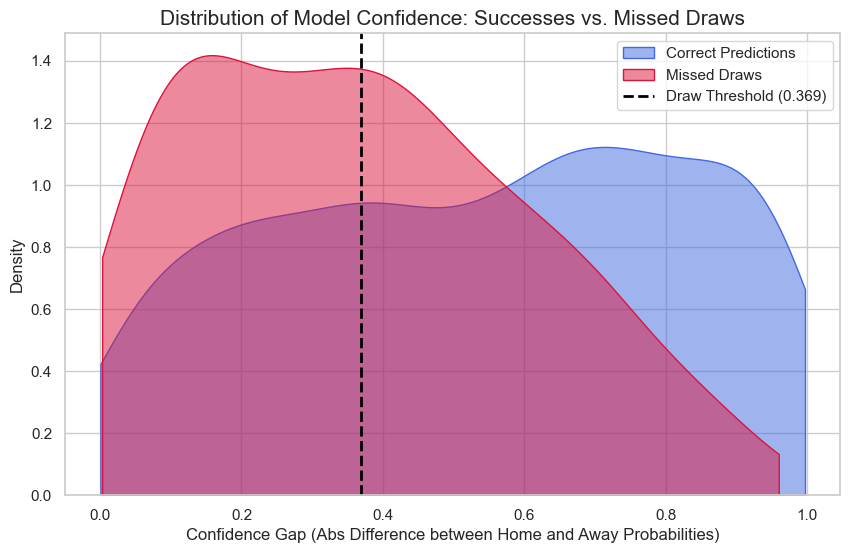

In [8]:
print(wrong_preds_draws.describe())

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

sns.kdeplot(data=new[new['success'] == 1], x='diff', 
            fill=True, label='Correct Predictions', color='royalblue', alpha=0.5, cut = 0)

sns.kdeplot(data=wrong_preds_draws, x='diff', 
            fill=True, label='Missed Draws', color='crimson', alpha=0.5, cut = 0)

plt.axvline(x=draw_threshold, color='black', linestyle='--', linewidth=2, 
            label=f'Draw Threshold ({draw_threshold:.3f})')

plt.title('Distribution of Model Confidence: Successes vs. Missed Draws', fontsize=15)
plt.xlabel('Confidence Gap (Abs Difference between Home and Away Probabilities)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend()

plt.show()

The graph compares the distribution of the confidence gap between the correct predictions and the missed draws. due to the missed draws distribution being skewed left we can infer that that most of the missed draws occur when the model is unsure about a clear winner is essentially guessing.

The dotted line represents the draw thereshold, moving foreward if the model has a confidence rating below .369 it will predict a draw. 

In [ ]:
joblib.dump(xgb_model, 'world_cup_model.joblib')
joblib.dump(draw_threshold, 'draw_threshold.joblib')